In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Test paths and display labels
TESTS = {
    'test_1': 'Test 1',
    'test_2': 'Test 2',
    'test_3': 'Test 3',
}

DATASETS = ['ArtDL', 'ICONCLASS', 'wikidata']

# Model families: each maps model folder name -> display label
MODEL_FAMILIES = {
    'Gemini Flash Lite': {
        'gemini-2.5-flash-lite':         'Gemini 2.5 Flash Lite\n(2025)',
        'gemini-3.1-flash-lite-preview':  'Gemini 3.1 Flash Lite\n(2026)',
    },
    'Gemini Flash': {
        'gemini-2.5-flash':       'Gemini 2.5 Flash\n(2025)',
        'gemini-3-flash-preview': 'Gemini 3 Flash\n(2026)',
    },
    'Gemini Pro': {
        'gemini-2.5-pro':         'Gemini 2.5 Pro\n(2025)',
        'gemini-3.1-pro-preview': 'Gemini 3.1 Pro\n(2026)',
    },
    'GPT Mini': {
        'gpt-4o-mini-2024-07-18': 'GPT-4o mini\n(2024)',
        'gpt-5-mini-2025-08-07':  'GPT-5 mini\n(2025)',
    },
    'GPT Full': {
        'gpt-4o-2024-11-20':   'GPT-4o\n(2024)',
        'gpt-5.2-2025-12-11':  'GPT-5.2\n(2025)',
    },
}

# Elegant, muted color palette (Tableau-inspired)
TEST_COLORS = {
    'test_1': '#4e79a7',  # steel blue
    'test_2': '#e15759',  # muted red
    'test_3': '#59a14f',  # sage green
}


def load_accuracy(test_path, dataset, model_name):
    """Return accuracy as a float (0-1) or None if not available."""
    csv = os.path.join(test_path, dataset, model_name, 'summary_metrics.csv')
    if not os.path.exists(csv):
        return None
    df = pd.read_csv(csv)
    rows = df.loc[df['Model'] == model_name, 'Accuracy']
    if rows.empty:
        return None
    val = rows.values[0]
    if isinstance(val, str):
        return float(val.rstrip('%')) / 100.0
    return float(val)


def collect_data():
    """
    Returns a nested dict:
        data[dataset][family_name][test_key] = list of (x_label, accuracy) pairs
    """
    data = {}
    for dataset in DATASETS:
        data[dataset] = {}
        for family_name, models in MODEL_FAMILIES.items():
            data[dataset][family_name] = {}
            for test_key in TESTS:
                points = []
                for model_id, x_label in models.items():
                    acc = load_accuracy(test_key, dataset, model_id)
                    points.append((x_label, acc))
                data[dataset][family_name][test_key] = points
    return data


data = collect_data()
print('Data loaded.')


Data loaded.


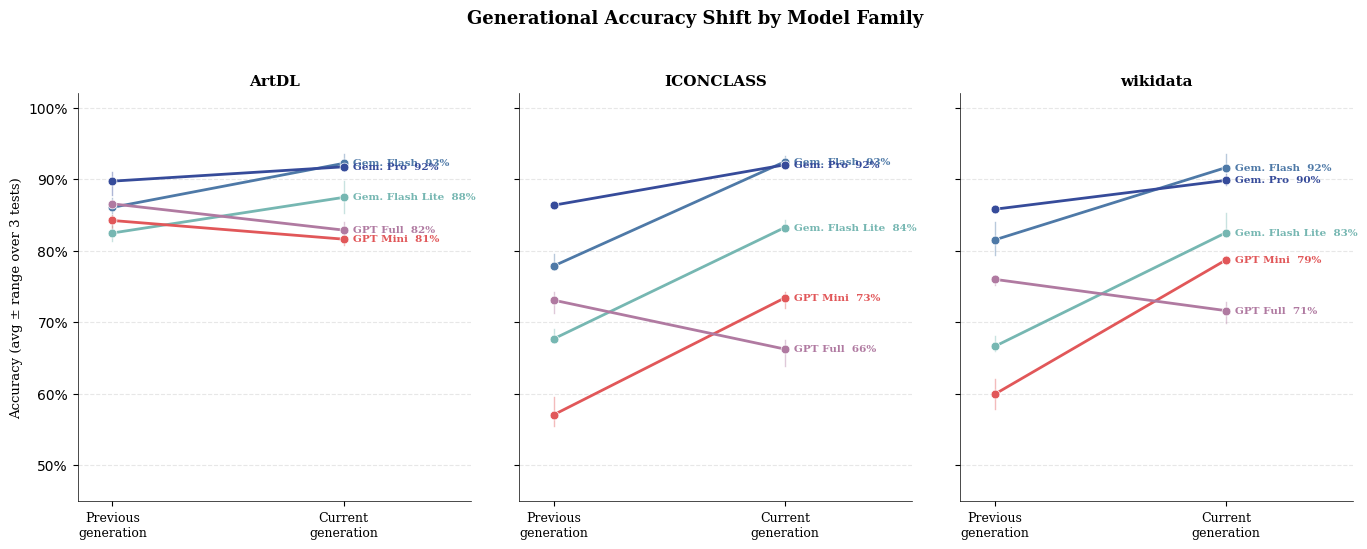

Saved: generation_compare.png / .pdf


In [2]:

# ── Chart 1: Slope chart — old vs new generation accuracy ────────────────────
# One panel per dataset, all 5 families shown as connected slopes.
# Averaged across 3 tests; whiskers show min/max across tests.

import numpy as np

family_names = list(MODEL_FAMILIES.keys())
family_short = {
    'Gemini Flash Lite': 'Gem. Flash Lite',
    'Gemini Flash': 'Gem. Flash',
    'Gemini Pro': 'Gem. Pro',
    'GPT Mini': 'GPT Mini',
    'GPT Full': 'GPT Full',
}

# Collect per-family, per-dataset: old/new mean and range
slope_data = {}
for dataset in DATASETS:
    slope_data[dataset] = []
    for family_name, models in MODEL_FAMILIES.items():
        model_ids = list(models.keys())
        old_accs, new_accs = [], []
        for test_key in TESTS:
            o = load_accuracy(test_key, dataset, model_ids[0])
            n = load_accuracy(test_key, dataset, model_ids[1])
            if o is not None: old_accs.append(o)
            if n is not None: new_accs.append(n)
        if old_accs and new_accs:
            slope_data[dataset].append({
                'family': family_name,
                'old_mean': np.mean(old_accs),
                'new_mean': np.mean(new_accs),
                'old_min': np.min(old_accs), 'old_max': np.max(old_accs),
                'new_min': np.min(new_accs), 'new_max': np.max(new_accs),
            })

# Colors per family
fam_colors = {
    'Gemini Flash Lite': '#76B7B2',
    'Gemini Flash':      '#4E79A7',
    'Gemini Pro':        '#364B9A',
    'GPT Mini':          '#E15759',
    'GPT Full':          '#B07AA1',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)
fig.suptitle('Generational Accuracy Shift by Model Family',
             fontsize=13, fontweight='bold', fontfamily='serif', y=0.99)

for ax, dataset in zip(axes, DATASETS):
    entries = slope_data[dataset]
    n = len(entries)

    for i, e in enumerate(entries):
        c = fam_colors[e['family']]
        y_offset = (i - n / 2) * 0.003  # tiny vertical jitter to avoid overlap

        # Slope line
        ax.plot([0, 1],
                [e['old_mean'] + y_offset, e['new_mean'] + y_offset],
                color=c, linewidth=2, solid_capstyle='round', zorder=3)

        # Min-max whiskers
        ax.plot([0, 0], [e['old_min'], e['old_max']],
                color=c, linewidth=1, alpha=0.4, zorder=2)
        ax.plot([1, 1], [e['new_min'], e['new_max']],
                color=c, linewidth=1, alpha=0.4, zorder=2)

        # Dots
        ax.scatter([0], [e['old_mean'] + y_offset], color=c, s=40,
                   zorder=4, edgecolors='white', linewidth=0.5)
        ax.scatter([1], [e['new_mean'] + y_offset], color=c, s=40,
                   zorder=4, edgecolors='white', linewidth=0.5)

        # Label on right side
        ax.text(1.04, e['new_mean'] + y_offset,
                f"{family_short[e['family']]}  {e['new_mean']:.0%}",
                fontsize=7.5, fontfamily='serif', va='center', color=c,
                fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Previous\ngeneration', 'Current\ngeneration'],
                       fontsize=9, fontfamily='serif')
    ax.set_xlim(-0.15, 1.55)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0.45, 1.02)
    ax.set_title(dataset, fontsize=11, fontweight='bold', fontfamily='serif')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

axes[0].set_ylabel('Accuracy (avg ± range over 3 tests)',
                    fontsize=9.5, fontfamily='serif')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('generation_compare.png', dpi=300, bbox_inches='tight')
plt.savefig('generation_compare.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: generation_compare.png / .pdf')


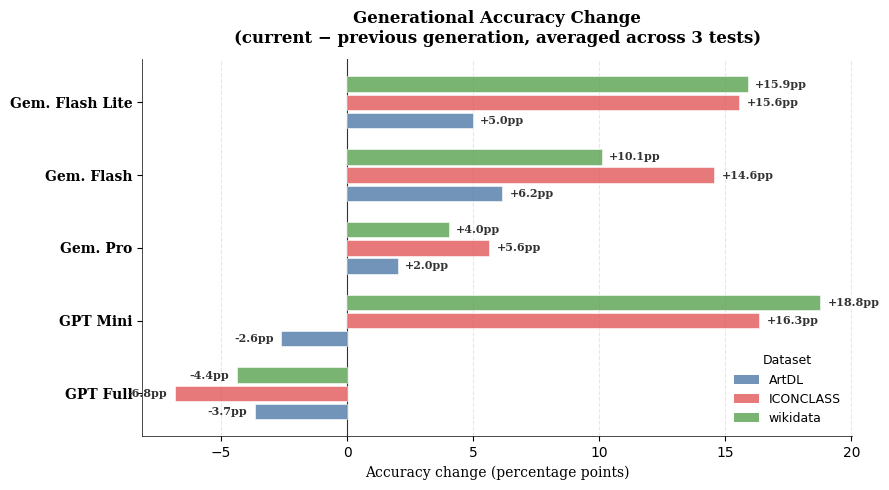

Saved: generation_extremes.png / .pdf


In [3]:

# ── Chart 2: Delta bar chart — accuracy change per family × dataset ──────────
# Horizontal bars, one row per family, grouped by dataset.
# Green = improvement, red = regression.

import numpy as np

family_short = {
    'Gemini Flash Lite': 'Gem. Flash Lite',
    'Gemini Flash': 'Gem. Flash',
    'Gemini Pro': 'Gem. Pro',
    'GPT Mini': 'GPT Mini',
    'GPT Full': 'GPT Full',
}

# Compute deltas (avg across 3 tests)
records = []
for family_name, models in MODEL_FAMILIES.items():
    model_ids = list(models.keys())
    for dataset in DATASETS:
        old_accs, new_accs = [], []
        for test_key in TESTS:
            o = load_accuracy(test_key, dataset, model_ids[0])
            n = load_accuracy(test_key, dataset, model_ids[1])
            if o is not None: old_accs.append(o)
            if n is not None: new_accs.append(n)
        if old_accs and new_accs:
            delta = np.mean(new_accs) - np.mean(old_accs)
            records.append({
                'family': family_name,
                'dataset': dataset,
                'delta': delta,
            })

df = pd.DataFrame(records)

# Layout: one group per family, bars for each dataset
families = list(MODEL_FAMILIES.keys())
n_fam = len(families)
n_ds = len(DATASETS)
bar_h = 0.22
ds_colors = {'ArtDL': '#4E79A7', 'ICONCLASS': '#E15759', 'wikidata': '#59A14F'}

fig, ax = plt.subplots(figsize=(9, 5))

y_positions = []
y_labels = []
for i, fam in enumerate(reversed(families)):  # reverse so top = first family
    base_y = i * (n_ds + 1) * bar_h
    for j, ds in enumerate(DATASETS):
        row = df[(df['family'] == fam) & (df['dataset'] == ds)]
        if row.empty:
            continue
        delta = row['delta'].values[0]
        y = base_y + j * bar_h
        c = '#2ca02c' if delta >= 0 else '#d62728'

        ax.barh(y, delta * 100, height=bar_h * 0.85,
                color=ds_colors[ds], alpha=0.8,
                edgecolor='white', linewidth=0.5, zorder=3)

        # Value label
        sign = '+' if delta >= 0 else ''
        nudge = 0.3 if delta >= 0 else -0.3
        ha = 'left' if delta >= 0 else 'right'
        ax.text(delta * 100 + nudge, y,
                f'{sign}{delta*100:.1f}pp',
                va='center', ha=ha, fontsize=8, fontfamily='serif',
                fontweight='bold', color='#333')

    y_positions.append(base_y + (n_ds - 1) * bar_h / 2)
    y_labels.append(family_short[fam])

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=10, fontfamily='serif', fontweight='bold')
ax.axvline(0, color='#333', linewidth=0.8, zorder=2)
ax.set_xlabel('Accuracy change (percentage points)', fontsize=10, fontfamily='serif')
ax.set_title('Generational Accuracy Change\n(current − previous generation, averaged across 3 tests)',
             fontsize=12, fontweight='bold', fontfamily='serif', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Dataset legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=ds_colors[ds], label=ds, alpha=0.8) for ds in DATASETS]
ax.legend(handles=legend_handles, fontsize=9, frameon=False,
          loc='lower right', title='Dataset', title_fontsize=9)

plt.tight_layout()
plt.savefig('generation_extremes.png', dpi=300, bbox_inches='tight')
plt.savefig('generation_extremes.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: generation_extremes.png / .pdf')
